In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

from utils import preprocess_data

RANDOM_STATE = 36

# Loading Data

In [223]:
df_train = pd.read_csv('data/train.csv') # With Target
df_test= pd.read_csv('data/test.csv') # No Target
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Preprocessing Data

In [224]:
X_train = df_train.drop(columns='Transported')
y_train = df_train['Transported']

X_train, median = preprocess_data(X_train)
X_test, _ = preprocess_data(
    df_test,
    median,
    X_train.columns
)

print(X_train.shape, X_test.shape)
X_test.head()


(8693, 27) (4277, 27)


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpendings,HomePlanet_Europa,HomePlanet_Mars,HomePlanet_Unknown,...,CabinDeck_B,CabinDeck_C,CabinDeck_D,CabinDeck_E,CabinDeck_F,CabinDeck_G,CabinDeck_T,CabinDeck_Unknown,CabinSide_S,CabinSide_Unknown
0,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
1,19.0,0.0,9.0,0.0,2823.0,0.0,2832.0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,31.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
3,38.0,0.0,6652.0,0.0,181.0,585.0,7418.0,1,0,0,...,0,1,0,0,0,0,0,0,1,0
4,20.0,10.0,0.0,635.0,0.0,0.0,645.0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


# Train Val Splitting Train Data

In [225]:
X_train, X_cv, y_train, y_cv = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)
print(X_train.shape, X_cv.shape, y_train.shape, y_cv.shape)

(6954, 27) (1739, 27) (6954,) (1739,)


# Training Tree Model

In [ ]:
reg_lambdas = [0, 0.01, 0.1, 0.5, 1, 2, 5, 10]
best_train_loss = []
best_cv_loss = []

for num in reg_lambdas:
    model = XGBClassifier(
        n_estimators = 500,
        learning_rate = 0.045,
        max_depth = 5,
        subsample = 0.8,
        colsample_bytree =0.5,
        min_child_weight = 1,
        alpha = 0.1,
        reg_lambda = 1,
        random_state = RANDOM_STATE,
        eval_metric = "logloss",
        early_stopping_rounds=20
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_cv, y_cv)],
        verbose=False
    )
    
    results = model.evals_result()
    train_loss = results['validation_0']['logloss']
    cv_loss = results['validation_1']['logloss']
    
    best_train_loss.append(min(train_loss))
    best_cv_loss.append(min(cv_loss))


# Predicting
ypred_train = model.predict(X_train)
ypred_cv = model.predict(X_cv)

In [227]:
print(best_cv_loss)
print('max Depth Value:', reg_lambdas[np.argmin(best_cv_loss)])
print(min(best_cv_loss))

[0.40941647489885813, 0.4119508074294407, 0.4076227783440199, 0.40677032508452415, 0.4065651213372931, 0.4134583653656679, 0.4100183558660624, 0.41262695590756315]
max Depth Value: 1
0.4065651213372931


# Evaluating Predictions

### Evaluating: Train set Predictions

In [228]:
# accuracy_score_train =  accuracy_score(y_train, ypred_train)
# confusion_matrix_train =  confusion_matrix(y_train, ypred_train)
# classification_report_train =  classification_report(y_train, ypred_train)

# print('Accuracy:', accuracy_score_train)
# print(confusion_matrix_train)
# print(classification_report_train)

### Evaluating: Test set Predictions

In [229]:
accuracy_score_cv =  accuracy_score(y_cv, ypred_cv)
confusion_matrix_cv =  confusion_matrix(y_cv, ypred_cv)
classification_report_cv =  classification_report(y_cv, ypred_cv)

print('Accuracy:', accuracy_score_cv)
print(confusion_matrix_cv)
print(classification_report_cv)


Accuracy: 0.7998849913743531
[[656 191]
 [157 735]]
              precision    recall  f1-score   support

       False       0.81      0.77      0.79       847
        True       0.79      0.82      0.81       892

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



In [230]:
print(train_loss)

[0.6792948574796298, 0.6666705988846807, 0.6548344873305467, 0.6432449498291772, 0.6316132875808121, 0.6208822163342058, 0.6111755020185761, 0.6071023987453492, 0.5980951951895427, 0.5920952174567202, 0.5845162050885855, 0.5770230408429002, 0.5698597584437254, 0.5643058035063064, 0.5574225812961838, 0.5526207715984319, 0.5479006709331131, 0.5436864731416025, 0.5392487244784986, 0.532268930804054, 0.5274026441118105, 0.5232223503276607, 0.519225970804177, 0.5149154859089563, 0.5117813944259456, 0.5087771062231078, 0.5050209706366868, 0.5013453351151063, 0.4980677379563618, 0.4947326701645506, 0.4909915850873579, 0.487182707447309, 0.4843015980242243, 0.48115269832049495, 0.4786749415427472, 0.47765113684400456, 0.4751017826202446, 0.47300101303449127, 0.47033248485411794, 0.46865931411078515, 0.4663530006181896, 0.4642202432053354, 0.46205049076701227, 0.459561020691941, 0.45775435910888845, 0.4562180567878843, 0.45433088994258464, 0.4523890819309479, 0.4506770312413252, 0.4490320150978

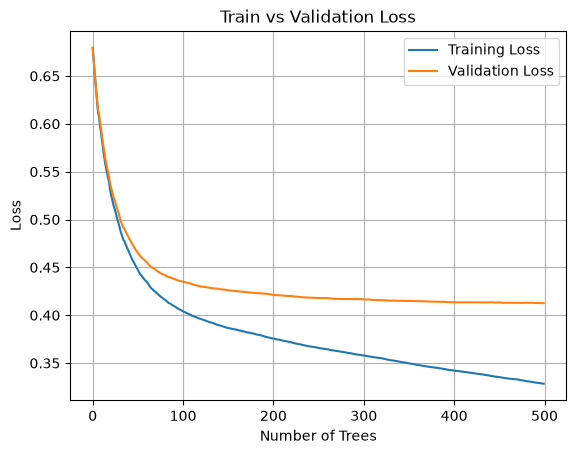

In [231]:
# results = model.evals_result()
# train_loss = results['validation_0']['logloss']
# cv_loss = results['validation_1']['logloss']

plt.plot(train_loss, label='Training Loss')
plt.plot(cv_loss, label='Validation Loss')
plt.title('Train vs Validation Loss')
plt.xlabel('Number of Trees')
plt.ylabel('Loss')
plt.legend()
plt.grid(0.8)